# 08｜Forensics Adapter 跨資料集測試

載入 07 在 FF++ 訓練完成的最佳權重，在 HiDF 與 Celeb-DF v2 上推論。設定與 04 對基準模型所做的測試完全對應，兩者可直接比較。

評估原則：

- 不使用外部資料集重新訓練、選模或調整門檻，門檻固定 0.5。
- 前處理完全沿用 07：256×256、CLIP mean/std、無隨機增強。
- 外部資料不需要 mask。mask 僅用於訓練階段的輔助監督，推論時不使用。
- 保留 frame-level 結果，並依來源 ID 平均為 video-level。

## 1. 套件與環境

In [1]:
from pathlib import Path
import json
import math
import os
import platform
import random
import re
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = [
            "Noto Sans CJK TC",
            "Noto Sans CJK SC",
            "WenQuanYi Zen Hei",
        ]
    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))


Python： 3.10.19
PyTorch： 2.5.1+cu121
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 2. 設定

`MAX_IMAGES_PER_DATASET` 必須為 `None`，否則類別比例被破壞，指標不能作為正式結果。

In [2]:
# 通常只需要確認這一格的路徑
FORENSICS_ADAPTER_DIR = Path("./ForensicsAdapter")
CLIP_WEIGHTS_DIR = Path("./ForensicsAdapter_Weights")

BEST_MODEL_PATH = Path(
    "./ForensicsAdapter_Results/"
    "ffpp_original_deepfakes_full/best_model.pth"
)
FFPP_TEST_METRICS_PATH = Path(
    "./ForensicsAdapter_Results/"
    "ffpp_original_deepfakes_full/test_metrics.json"
)

HIDF_ROOT = Path(r"D:\資料\專題\PY\deepfake\研討會\dataset_HiDF5000\test")
CELEBDF_ROOT = Path(r"D:\資料\專題\PY\deepfake\研討會(二)\CelebDF_v2_balanced_test\test")
DATASET_ROOTS = {
    "HiDF": HIDF_ROOT,
    "CelebDF_v2": CELEBDF_ROOT,
}

OUTPUT_ROOT = Path(
    "./ForensicsAdapter_Results/"
    "ffpp_original_deepfakes_full_cross_dataset"
)

IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 0
SEED = 42
THRESHOLD = 0.5

# 正式結果必須使用 None；只想快速檢查流程時可暫時設為 100。
MAX_IMAGES_PER_DATASET = None

# 預設直接執行正式跨資料集測試。
RUN_EVALUATION = True

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

print("官方專案：", FORENSICS_ADAPTER_DIR.resolve())
print("最佳模型：", BEST_MODEL_PATH.resolve())
print("HiDF：", HIDF_ROOT.resolve())
print("Celeb-DF：", CELEBDF_ROOT.resolve())
print("輸出：", OUTPUT_ROOT.resolve())
print("裝置：", DEVICE)


官方專案： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter
最佳模型： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter_Results\ffpp_original_deepfakes_full\best_model.pth
HiDF： D:\資料\專題\PY\deepfake\研討會\dataset_HiDF5000\test
Celeb-DF： D:\資料\專題\PY\deepfake\研討會(二)\CelebDF_v2_balanced_test\test
輸出： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter_Results\ffpp_original_deepfakes_full_cross_dataset
裝置： cuda:0


## 3. 固定隨機種子並檢查必要檔案

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

required_files = [
    FORENSICS_ADAPTER_DIR / "model" / "ds.py",
    FORENSICS_ADAPTER_DIR / "model" / "adapters" / "adapter.py",
    BEST_MODEL_PATH,
]
missing = [str(path.resolve()) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError("缺少必要檔案：\n" + "\n".join(missing))

for dataset_name, root in DATASET_ROOTS.items():
    if not root.is_dir():
        raise FileNotFoundError(
            f"{dataset_name} 資料夾不存在：{root.resolve()}"
        )

CLIP_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
if DEVICE.type != "cuda":
    print("提醒：目前使用 CPU，ViT-L/14 推論會非常慢。")
print("必要檔案與資料夾檢查完成。")


必要檔案與資料夾檢查完成。


## 4. 掃描外部資料並解析來源 ID

標籤只由 `real`／`fake` 資料夾決定，檔名僅用於還原 `video_id`。

In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
LABEL_MAPPING = {"real": 0, "fake": 1}


def find_class_name(path, root):
    relative_parts = [part.lower() for part in path.relative_to(root).parts]
    matches = [
        part for part in relative_parts[:-1]
        if part in LABEL_MAPPING
    ]
    if not matches:
        raise ValueError(f"圖片不在 real／fake 資料夾下：{path}")
    return matches[-1]


def parse_video_id(dataset_name, image_path, class_name):
    stem = image_path.stem

    if dataset_name == "CelebDF_v2":
        # real_00011_f000047 -> real_00011
        # fake_id0_id1_0001_f000030 -> fake_id0_id1_0001
        return re.sub(r"_f\d+$", "", stem, flags=re.IGNORECASE)

    if dataset_name == "HiDF":
        # Fake: c00046_c00110... -> c00046_c00110
        # Real: c00048... -> c00048
        if class_name == "fake":
            match = re.match(
                r"^(c\d+_c\d+)",
                stem,
                flags=re.IGNORECASE,
            )
        else:
            match = re.match(
                r"^(c\d+)",
                stem,
                flags=re.IGNORECASE,
            )
        if match:
            return match.group(1)
        return re.sub(
            r"_(?:f|frame)\d+$",
            "",
            stem,
            flags=re.IGNORECASE,
        )

    return re.sub(r"_f\d+$", "", stem, flags=re.IGNORECASE)


def scan_dataset(dataset_name, root):
    paths = sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not paths:
        raise FileNotFoundError(
            f"{dataset_name} 找不到支援的圖片：{root.resolve()}"
        )

    records = []
    invalid_paths = []
    for path in paths:
        try:
            class_name = find_class_name(path, root)
        except ValueError:
            invalid_paths.append(path)
            continue
        video_id = parse_video_id(dataset_name, path, class_name)
        records.append({
            "dataset": dataset_name,
            "path": str(path.resolve()),
            "file_name": path.name,
            "class_name": class_name,
            "label": LABEL_MAPPING[class_name],
            "video_id": video_id,
            "video_key": f"{class_name}::{video_id}",
        })

    if invalid_paths:
        print(
            f"{dataset_name}：略過 {len(invalid_paths):,} 張"
            "不在 real／fake 資料夾下的圖片。"
        )

    dataframe = pd.DataFrame(records)
    if dataframe.empty:
        raise ValueError(f"{dataset_name} 沒有可用圖片。")
    if dataframe["label"].nunique() < 2:
        raise ValueError(f"{dataset_name} 必須同時包含 Real 與 Fake。")
    if dataframe["path"].duplicated().any():
        raise ValueError(f"{dataset_name} 發現重複圖片路徑。")

    if MAX_IMAGES_PER_DATASET is not None:
        sampled = []
        per_class = math.ceil(MAX_IMAGES_PER_DATASET / 2)
        for _, group in dataframe.groupby("class_name"):
            sampled.append(
                group.sample(
                    n=min(per_class, len(group)),
                    random_state=SEED,
                )
            )
        dataframe = (
            pd.concat(sampled, ignore_index=True)
            .head(MAX_IMAGES_PER_DATASET)
            .copy()
        )

    return dataframe.sort_values(
        ["class_name", "video_id", "file_name"]
    ).reset_index(drop=True)


dataset_frames = {
    name: scan_dataset(name, root)
    for name, root in DATASET_ROOTS.items()
}

summary_rows = []
for dataset_name, dataframe in dataset_frames.items():
    for class_name, group in dataframe.groupby("class_name"):
        summary_rows.append({
            "dataset": dataset_name,
            "class_name": class_name,
            "frame_count": len(group),
            "video_count": group["video_key"].nunique(),
        })

dataset_summary_df = pd.DataFrame(summary_rows)
display(dataset_summary_df)

for dataset_name, dataframe in dataset_frames.items():
    print(f"\n{dataset_name} 解析範例")
    display(
        dataframe[
            ["file_name", "class_name", "label", "video_id"]
        ].groupby("class_name", group_keys=False).head(3)
    )


,dataset,class_name,frame_count,video_count
0,HiDF,fake,313,313
1,HiDF,real,313,313
2,CelebDF_v2,fake,534,178
3,CelebDF_v2,real,534,178



HiDF 解析範例


,file_name,class_name,label,video_id
0,c00046_c00110.jpg,fake,1,c00046_c00110
1,c00128_c00121.jpg,fake,1,c00128_c00121
2,c00137_c00172.jpg,fake,1,c00137_c00172
313,c00048.jpg,real,0,c00048
314,c00057.jpg,real,0,c00057
315,c00096.jpg,real,0,c00096



CelebDF_v2 解析範例


,file_name,class_name,label,video_id
0,fake_id0_id16_0003_f000052.png,fake,1,fake_id0_id16_0003
1,fake_id0_id16_0003_f000090.png,fake,1,fake_id0_id16_0003
2,fake_id0_id16_0003_f000128.png,fake,1,fake_id0_id16_0003
534,real_00011_f000047.png,real,0,real_00011
535,real_00011_f000081.png,real,0,real_00011
536,real_00011_f000115.png,real,0,real_00011


### 解析結果檢查

確認標籤對應為 Real=0、Fake=1，且同一來源的影格具有相同 `video_id`。

## 5. 建立與 07 相同的前處理

尺寸 256×256，與 04 使用的 224×224 不同，因為兩個模型的輸入規格本就不同。同一模型在 FF++ 與外部資料上的前處理則完全一致，跨資料集的差異因此可歸因於資料本身。

In [5]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
normalize = transforms.Normalize(CLIP_MEAN, CLIP_STD)


def imread_unicode(path, flags=cv2.IMREAD_COLOR):
    path_string = os.fspath(path)
    if (
        platform.system() == "Windows"
        and any(ord(character) > 127 for character in path_string)
    ):
        encoded = np.fromfile(path_string, dtype=np.uint8)
        if encoded.size == 0:
            return None
        return cv2.imdecode(encoded, flags)
    return cv2.imread(path_string, flags)


class ExternalForensicsDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = Path(row["path"])
        image_bgr = imread_unicode(path, cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise FileNotFoundError(f"無法讀取圖片：{path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb = cv2.resize(
            image_rgb,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_CUBIC,
        )
        image = torch.from_numpy(
            image_rgb.transpose(2, 0, 1).copy()
        ).float().div(255.0)
        image = normalize(image)

        return {
            "image": image,
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            # 推論分類不使用外部資料的 Mask。這個零張量只用來符合
            # 官方 DS.forward() 的輸入介面，長度對應 16×16 patches。
            "if_boundary": torch.zeros(256, dtype=torch.long),
            "path": str(path),
            "file_name": str(row["file_name"]),
            "video_key": str(row["video_key"]),
            "video_id": str(row["video_id"]),
            "class_name": str(row["class_name"]),
            "dataset": str(row["dataset"]),
        }


dataloaders = {}
for dataset_name, dataframe in dataset_frames.items():
    dataset = ExternalForensicsDataset(dataframe)
    dataloaders[dataset_name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )
    print(
        f"{dataset_name}：{len(dataset):,} 張，"
        f"{len(dataloaders[dataset_name]):,} batches"
    )


HiDF：626 張，157 batches
CelebDF_v2：1,068 張，267 batches


## 6. 建立完整模型並載入 07 的最佳權重

In [6]:
ds_path = FORENSICS_ADAPTER_DIR / "model" / "ds.py"
ds_text = ds_path.read_text(encoding="utf-8")
hardcoded = "download_root='/data/cuixinjie/weights'"
replacement = f"download_root={str(CLIP_WEIGHTS_DIR.resolve())!r}"
if hardcoded in ds_text:
    backup_path = ds_path.with_suffix(".py.codex_backup")
    if not backup_path.exists():
        backup_path.write_text(ds_text, encoding="utf-8")
    ds_path.write_text(
        ds_text.replace(hardcoded, replacement),
        encoding="utf-8",
    )
    print("已將 CLIP 權重快取改為：", CLIP_WEIGHTS_DIR.resolve())
elif replacement not in ds_text:
    print(
        "提醒：ds.py 的 download_root 已被修改過，"
        "請確認它仍指向可用的 CLIP 權重資料夾。"
    )

project_path = str(FORENSICS_ADAPTER_DIR.resolve())
if project_path not in sys.path:
    sys.path.insert(0, project_path)

from model.ds import DS


model = DS(
    clip_name="ViT-L/14",
    adapter_vit_name="vit_tiny_patch16_224",
    num_quires=128,
    fusion_map={1: 1, 2: 8, 3: 15},
    mlp_dim=256,
    mlp_out_dim=128,
    head_num=16,
    device=DEVICE,
).to(DEVICE)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)
if "model_state_dict" not in checkpoint:
    raise KeyError(
        "best_model.pth 中找不到 model_state_dict，"
        "請確認使用 07 產生的最佳模型。"
    )

load_result = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=False,
)
if load_result.unexpected_keys:
    raise RuntimeError(
        f"Checkpoint 含非預期參數：{load_result.unexpected_keys}"
    )

trainable_names = {
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
}
missing_trainable = sorted(
    trainable_names.intersection(load_result.missing_keys)
)
if missing_trainable:
    raise RuntimeError(
        "Checkpoint 缺少可訓練參數：\n"
        + "\n".join(missing_trainable)
    )

model.eval()
print("模型權重載入成功")
print("最佳 Epoch：", int(checkpoint.get("epoch", -1)) + 1)
print("最佳驗證 Video AUC：", checkpoint.get("best_val_auc", "未記錄"))
print("Checkpoint 參數數量：", len(checkpoint["model_state_dict"]))


width:1024 layers 24 
模型權重載入成功
最佳 Epoch： 5
最佳驗證 Video AUC： 0.9983163265306122
Checkpoint 參數數量： 207


## 7. 單一批次推論檢查

In [7]:
def model_batch(batch):
    return {
        "image": batch["image"].to(DEVICE, non_blocking=True),
        "label": batch["label"].to(DEVICE, non_blocking=True),
        "if_boundary": batch["if_boundary"].to(
            DEVICE,
            non_blocking=True,
        ),
    }


sample_dataset_name = next(iter(dataloaders))
sample_batch = next(iter(dataloaders[sample_dataset_name]))
sample_input = model_batch(sample_batch)

model.prob, model.label = [], []
model.correct, model.total = 0, 0
with torch.no_grad():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):
        sample_pred = model(sample_input, inference=True)

print("資料集：", sample_dataset_name)
print("image：", tuple(sample_input["image"].shape))
print("label：", sample_input["label"].tolist())
print("if_boundary：", tuple(sample_input["if_boundary"].shape))
print("P(Fake)：", sample_pred["prob"].detach().float().cpu().tolist())

model.prob, model.label = [], []
model.correct, model.total = 0, 0
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
print("單一 Batch 推論檢查完成。")


資料集： HiDF
image： (4, 3, 256, 256)
label： [1, 1, 1, 1]
if_boundary： (4, 256)
P(Fake)： [0.5113982558250427, 0.5155741572380066, 0.5290884971618652, 0.5092571973800659]
單一 Batch 推論檢查完成。


## 8. 指標與評估函式

In [8]:
def safe_auc(labels, probabilities):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    if np.unique(labels).size < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def binary_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "sample_count": int(len(labels)),
        "real_count": int((labels == 0).sum()),
        "fake_count": int((labels == 1).sum()),
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": safe_auc(labels, probabilities),
        "threshold": float(threshold),
    }


def aggregate_video_predictions(frame_df):
    label_counts = frame_df.groupby("video_key")["label"].nunique()
    if (label_counts > 1).any():
        raise ValueError("同一 video_key 出現不同標籤。")
    return (
        frame_df.groupby(
            ["dataset", "video_key", "video_id", "class_name"],
            as_index=False,
        )
        .agg(
            label=("label", "first"),
            fake_probability=("fake_probability", "mean"),
            frame_count=("fake_probability", "size"),
        )
    )


def evaluate_dataset(model, dataloader, dataset_name):
    records = []
    model.eval()
    model.prob, model.label = [], []
    model.correct, model.total = 0, 0

    with torch.no_grad():
        for batch in tqdm(
            dataloader,
            desc=f"Evaluate {dataset_name}",
        ):
            inputs = model_batch(batch)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                pred = model(inputs, inference=True)
            probabilities = pred["prob"].detach().float().cpu()

            for index in range(len(probabilities)):
                records.append({
                    "dataset": batch["dataset"][index],
                    "path": batch["path"][index],
                    "file_name": batch["file_name"][index],
                    "video_key": batch["video_key"][index],
                    "video_id": batch["video_id"][index],
                    "class_name": batch["class_name"][index],
                    "label": int(batch["label"][index]),
                    "fake_probability": float(probabilities[index]),
                })

    model.prob, model.label = [], []
    model.correct, model.total = 0, 0

    frame_df = pd.DataFrame(records)
    frame_df["prediction"] = (
        frame_df["fake_probability"] >= THRESHOLD
    ).astype(int)

    video_df = aggregate_video_predictions(frame_df)
    video_df["prediction"] = (
        video_df["fake_probability"] >= THRESHOLD
    ).astype(int)

    frame_metrics = binary_metrics(
        frame_df["label"],
        frame_df["fake_probability"],
        THRESHOLD,
    )
    video_metrics = binary_metrics(
        video_df["label"],
        video_df["fake_probability"],
        THRESHOLD,
    )
    return frame_df, video_df, frame_metrics, video_metrics


## 9. 執行 HiDF 與 Celeb-DF 測試

In [9]:
evaluation_results = {}
metric_rows = []

if not RUN_EVALUATION:
    print("RUN_EVALUATION=False，尚未開始外部測試。")
else:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

    for dataset_name, dataloader in dataloaders.items():
        (
            frame_df,
            video_df,
            frame_metrics,
            video_metrics,
        ) = evaluate_dataset(model, dataloader, dataset_name)

        dataset_dir = OUTPUT_ROOT / dataset_name
        dataset_dir.mkdir(parents=True, exist_ok=True)

        frame_df.to_csv(
            dataset_dir / "frame_predictions.csv",
            index=False,
            encoding="utf-8-sig",
        )
        video_df.to_csv(
            dataset_dir / "video_predictions.csv",
            index=False,
            encoding="utf-8-sig",
        )

        metrics_payload = {
            "dataset": dataset_name,
            "method": "Full Forensics Adapter trained on FF++ Deepfakes",
            "checkpoint": str(BEST_MODEL_PATH.resolve()),
            "threshold_source": "fixed FF++ model threshold 0.5",
            "max_images_per_dataset": MAX_IMAGES_PER_DATASET,
            "frame_level": frame_metrics,
            "video_level": video_metrics,
        }
        with (dataset_dir / "metrics.json").open(
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                metrics_payload,
                file,
                ensure_ascii=False,
                indent=2,
            )

        evaluation_results[dataset_name] = {
            "frame_df": frame_df,
            "video_df": video_df,
            "frame_metrics": frame_metrics,
            "video_metrics": video_metrics,
        }

        for level, metrics in [
            ("frame", frame_metrics),
            ("video", video_metrics),
        ]:
            metric_rows.append({
                "dataset": dataset_name,
                "level": level,
                **metrics,
            })

        print()
        print(json.dumps(metrics_payload, ensure_ascii=False, indent=2))
        print("\nFrame-level Classification Report")
        print(classification_report(
            frame_df["label"],
            frame_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        ))
        print("Video-level Classification Report")
        print(classification_report(
            video_df["label"],
            video_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        ))

    external_metrics_df = pd.DataFrame(metric_rows)
    external_metrics_df.to_csv(
        OUTPUT_ROOT / "external_metrics_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(external_metrics_df)


Evaluate HiDF:   0%|          | 0/157 [00:00<?, ?it/s]


{
  "dataset": "HiDF",
  "method": "Full Forensics Adapter trained on FF++ Deepfakes",
  "checkpoint": "D:\\資料\\專題\\PY\\deepfake\\新版專題研究\\ForensicsAdapter_Results\\ffpp_original_deepfakes_full\\best_model.pth",
  "threshold_source": "fixed FF++ model threshold 0.5",
  "max_images_per_dataset": null,
  "frame_level": {
    "sample_count": 626,
    "real_count": 313,
    "fake_count": 313,
    "accuracy": 0.865814696485623,
    "precision": 0.9711934156378601,
    "recall": 0.7539936102236422,
    "f1": 0.8489208633093526,
    "auc": 0.9735018220049199,
    "threshold": 0.5
  },
  "video_level": {
    "sample_count": 626,
    "real_count": 313,
    "fake_count": 313,
    "accuracy": 0.865814696485623,
    "precision": 0.9711934156378601,
    "recall": 0.7539936102236422,
    "f1": 0.8489208633093526,
    "auc": 0.9735018220049199,
    "threshold": 0.5
  }
}

Frame-level Classification Report
              precision    recall  f1-score   support

        Real     0.7990    0.9776    0.87

Evaluate CelebDF_v2:   0%|          | 0/267 [00:00<?, ?it/s]


{
  "dataset": "CelebDF_v2",
  "method": "Full Forensics Adapter trained on FF++ Deepfakes",
  "checkpoint": "D:\\資料\\專題\\PY\\deepfake\\新版專題研究\\ForensicsAdapter_Results\\ffpp_original_deepfakes_full\\best_model.pth",
  "threshold_source": "fixed FF++ model threshold 0.5",
  "max_images_per_dataset": null,
  "frame_level": {
    "sample_count": 1068,
    "real_count": 534,
    "fake_count": 534,
    "accuracy": 0.6750936329588015,
    "precision": 0.8978723404255319,
    "recall": 0.3951310861423221,
    "f1": 0.5487646293888166,
    "auc": 0.7868254569428663,
    "threshold": 0.5
  },
  "video_level": {
    "sample_count": 356,
    "real_count": 178,
    "fake_count": 178,
    "accuracy": 0.6769662921348315,
    "precision": 0.8987341772151899,
    "recall": 0.398876404494382,
    "f1": 0.5525291828793775,
    "auc": 0.8063060219669234,
    "threshold": 0.5
  }
}

Frame-level Classification Report
              precision    recall  f1-score   support

        Real     0.6122    0.9551

,dataset,level,sample_count,real_count,fake_count,accuracy,precision,recall,f1,auc,threshold
0,HiDF,frame,626,313,313,0.865815,0.971193,0.753994,0.848921,0.973502,0.5
1,HiDF,video,626,313,313,0.865815,0.971193,0.753994,0.848921,0.973502,0.5
2,CelebDF_v2,frame,1068,534,534,0.675094,0.897872,0.395131,0.548765,0.786825,0.5
3,CelebDF_v2,video,356,178,178,0.676966,0.898734,0.398876,0.552529,0.806306,0.5


## 10. 混淆矩陣與 ROC Curve

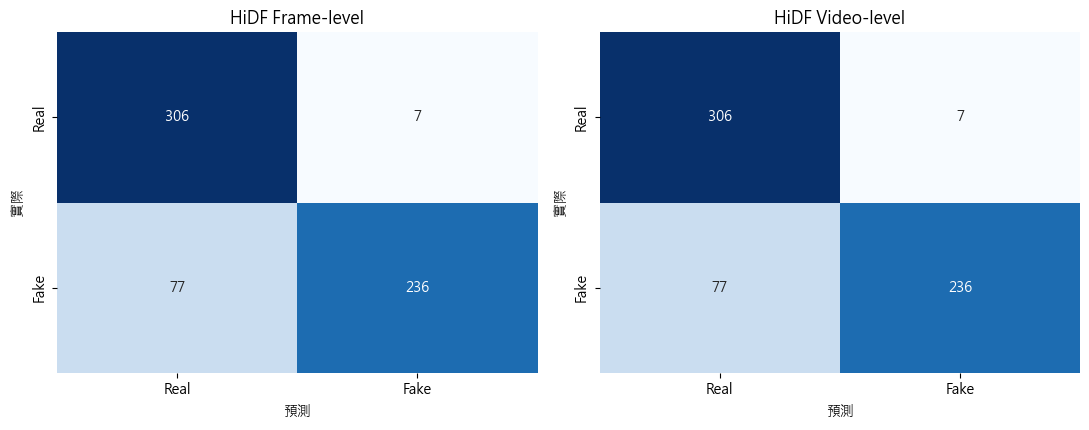

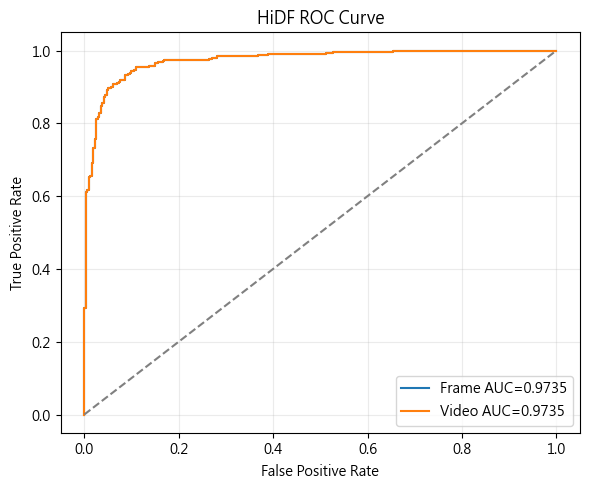

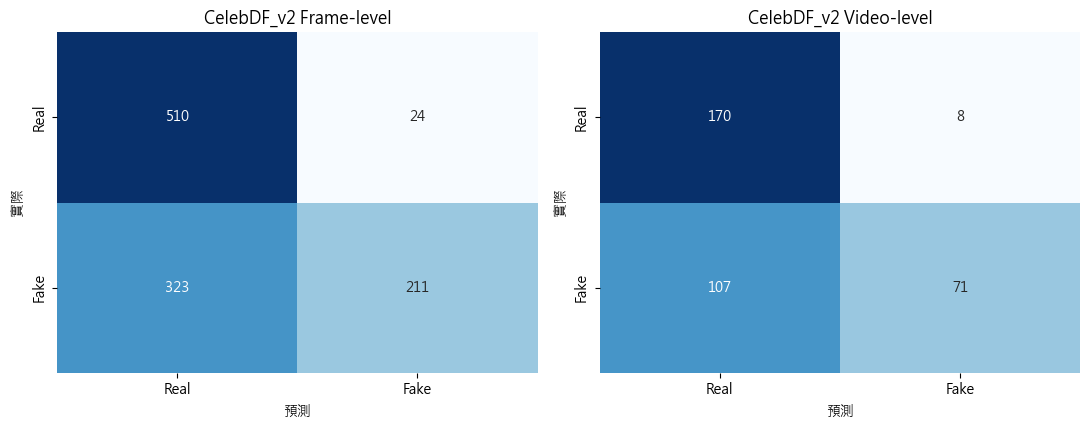

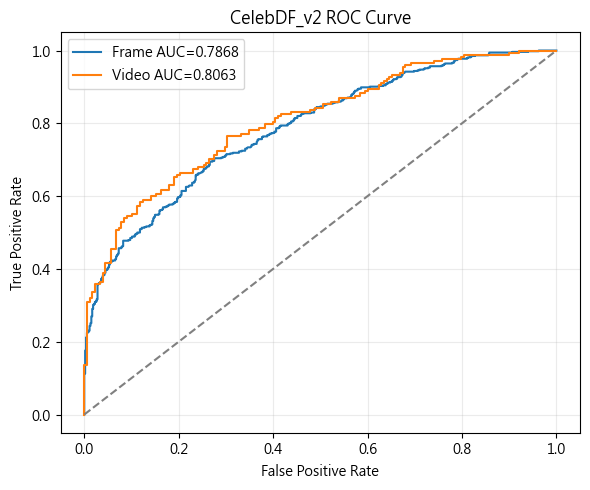

In [10]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    for dataset_name, result in evaluation_results.items():
        dataset_dir = OUTPUT_ROOT / dataset_name
        frame_df = result["frame_df"]
        video_df = result["video_df"]
        frame_metrics = result["frame_metrics"]
        video_metrics = result["video_metrics"]

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
        for axis, dataframe, title in [
            (axes[0], frame_df, "Frame-level"),
            (axes[1], video_df, "Video-level"),
        ]:
            matrix = confusion_matrix(
                dataframe["label"],
                dataframe["prediction"],
                labels=[0, 1],
            )
            sns.heatmap(
                matrix,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"],
                ax=axis,
            )
            axis.set_title(f"{dataset_name} {title}")
            axis.set_xlabel("預測")
            axis.set_ylabel("實際")

        plt.tight_layout()
        plt.savefig(
            dataset_dir / "confusion_matrices.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()

        plt.figure(figsize=(6, 5))
        for dataframe, metrics, level_name in [
            (frame_df, frame_metrics, "Frame"),
            (video_df, video_metrics, "Video"),
        ]:
            fpr, tpr, _ = roc_curve(
                dataframe["label"],
                dataframe["fake_probability"],
            )
            plt.plot(
                fpr,
                tpr,
                label=f"{level_name} AUC={metrics['auc']:.4f}",
            )

        plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{dataset_name} ROC Curve")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(
            dataset_dir / "roc_curve.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()


## 11. 三個資料集結果彙整

,dataset,level,accuracy,precision,recall,f1,auc,auc_drop_vs_ffpp
0,FFPP,frame,0.937054,0.963103,0.908929,0.935232,0.981428,0.000000
1,FFPP,video,0.953571,0.977444,0.928571,0.952381,0.987755,0.000000
2,HiDF,frame,0.865815,0.971193,0.753994,0.848921,0.973502,0.007926
3,HiDF,video,0.865815,0.971193,0.753994,0.848921,0.973502,0.014253
4,CelebDF_v2,frame,0.675094,0.897872,0.395131,0.548765,0.786825,0.194603
5,CelebDF_v2,video,0.676966,0.898734,0.398876,0.552529,0.806306,0.181449


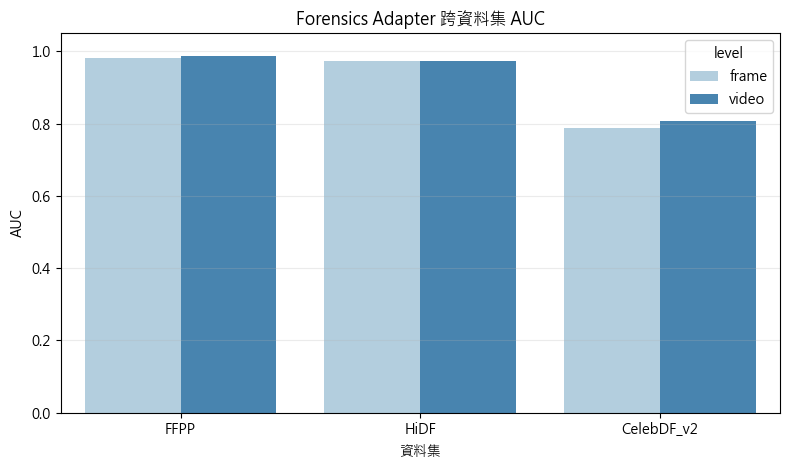

In [11]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    comparison_rows = []

    if FFPP_TEST_METRICS_PATH.is_file():
        with FFPP_TEST_METRICS_PATH.open(
            "r",
            encoding="utf-8",
        ) as file:
            ffpp_metrics = json.load(file)

        for level, source_key in [
            ("frame", "frame_level"),
            ("video", "video_level"),
        ]:
            metrics = ffpp_metrics[source_key]
            comparison_rows.append({
                "dataset": "FFPP",
                "level": level,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
            })
    else:
        print(
            "找不到 FF++ test_metrics.json，"
            "本次只整理 HiDF 與 Celeb-DF。"
        )

    for dataset_name, result in evaluation_results.items():
        for level, metrics in [
            ("frame", result["frame_metrics"]),
            ("video", result["video_metrics"]),
        ]:
            comparison_rows.append({
                "dataset": dataset_name,
                "level": level,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
            })

    comparison_df = pd.DataFrame(comparison_rows)
    ffpp_auc_map = (
        comparison_df[
            comparison_df["dataset"].eq("FFPP")
        ].set_index("level")["auc"].to_dict()
    )
    comparison_df["auc_drop_vs_ffpp"] = comparison_df.apply(
        lambda row: (
            ffpp_auc_map.get(row["level"], np.nan) - row["auc"]
            if row["dataset"] != "FFPP"
            else 0.0
        ),
        axis=1,
    )
    comparison_df.to_csv(
        OUTPUT_ROOT / "all_dataset_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(comparison_df)

    plt.figure(figsize=(8, 4.8))
    sns.barplot(
        data=comparison_df,
        x="dataset",
        y="auc",
        hue="level",
        palette="Blues",
    )
    plt.ylim(0, 1.05)
    plt.ylabel("AUC")
    plt.xlabel("資料集")
    plt.title("Forensics Adapter 跨資料集 AUC")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / "cross_dataset_auc.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 12. 高信心誤判案例

原本此處為 HiDF 與 Celeb-DF 的誤判樣本影像，因兩個資料集的授權條款限制影像再散布，已於公開版本移除。程式碼保留，可在本機重現。

In [12]:
if not evaluation_results:
    print("尚未完成外部測試。")
else:
    for dataset_name, result in evaluation_results.items():
        frame_df = result["frame_df"]
        errors_df = frame_df[
            frame_df["label"] != frame_df["prediction"]
        ].copy()
        errors_df["error_confidence"] = np.where(
            errors_df["prediction"].eq(1),
            errors_df["fake_probability"],
            1.0 - errors_df["fake_probability"],
        )
        errors_df = errors_df.sort_values(
            "error_confidence",
            ascending=False,
        )
        errors_df.to_csv(
            OUTPUT_ROOT / dataset_name / "error_cases.csv",
            index=False,
            encoding="utf-8-sig",
        )

        sample_count = min(12, len(errors_df))
        print(
            f"{dataset_name} Frame-level 誤判："
            f"{len(errors_df):,} 張"
        )
        if sample_count == 0:
            continue

        samples = errors_df.head(sample_count)
        columns = 4
        rows = math.ceil(sample_count / columns)
        fig, axes = plt.subplots(
            rows,
            columns,
            figsize=(12, 3 * rows),
        )
        axes = np.array(axes).reshape(-1)

        for axis, (_, row) in zip(axes, samples.iterrows()):
            image_bgr = imread_unicode(row["path"], cv2.IMREAD_COLOR)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            axis.imshow(image_rgb)
            axis.set_title(
                f"實際={row['class_name']}\n"
                f"P(Fake)={row['fake_probability']:.3f}"
            )
            axis.axis("off")

        for axis in axes[sample_count:]:
            axis.axis("off")

        plt.suptitle(f"{dataset_name} 高信心誤判案例")
        plt.tight_layout()
        plt.show()


HiDF Frame-level 誤判：84 張


CelebDF_v2 Frame-level 誤判：347 張


## 跨資料集結果與基準比較

**Forensics Adapter（本 Notebook）**

| 資料集 | 層級 | Accuracy | Recall | AUC | AUC 相對 FF++ 下降 |
|---|---|---|---|---|---|
| FF++ | frame | 0.9371 | 0.9089 | 0.9814 | — |
| FF++ | video | 0.9536 | 0.9286 | 0.9878 | — |
| HiDF | frame | 0.8658 | 0.7540 | 0.9735 | 0.008 |
| Celeb-DF v2 | frame | 0.6751 | 0.3951 | 0.7868 | 0.195 |
| Celeb-DF v2 | video | 0.6770 | 0.3989 | 0.8063 | 0.181 |

**與 CLIP 基準（04）的 AUC 對照**

| 資料集 | CLIP 基準 | Forensics Adapter | 差距 |
|---|---|---|---|
| FF++ (video) | 0.9805 | 0.9878 | +0.007 |
| HiDF | 0.8083 | 0.9735 | **+0.165** |
| Celeb-DF v2 (frame) | 0.6770 | 0.7868 | **+0.110** |
| Celeb-DF v2 (video) | 0.6958 | 0.8063 | **+0.111** |

兩個模型在 FF++ 上的差距僅 0.007，在外部資料集上拉開到 0.11–0.17。這是本專案最主要的結果：**Adapter 的價值不在訓練分布內的準確率，而在跨分布時的穩定性**。若只看 FF++ 表格，會得出「兩個方法差不多」的結論。

HiDF 的 AUC 僅下降 0.008，幾乎沒有衰減；Celeb-DF v2 仍下降 0.18–0.19。兩個外部資料集的困難程度差異很大，不宜以單一資料集代表「泛化能力」。

recall 的問題仍然存在：Celeb-DF v2 上 precision 0.898 但 recall 僅 0.395，模型依然過度保守。這與 04 觀察到的現象一致，且不因換用更強的方法而消失——**固定門檻 0.5 在跨 domain 時失效，是與模型能力相對獨立的問題**。09A–09C 針對這一點做進一步驗證。